# Quick morphology visualization notebook

Compact, dependency-light tools for inspecting SNT / ImageJ morphology output:

- `*.swc`: skeleton nodes in micron coordinates
- `*.traces`: gzipped SNT XML paths, useful for sanity-checking individual traced paths
- `SNT Measurements.csv`, `QuickMeasurements.csv`, `Sholl_Table*.csv`: exported summary measurements
- optional original TIFF stack for image/MIP overlay

Set `DATA_DIR` below to a reconstruction folder containing these files. The notebook will auto-discover the first matching files in that folder.

In [3]:
import re
import os
import glob
import gzip
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from IPython.display import display
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection

from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [4]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures"

In [7]:
REPO_ROOT = None

if REPO_ROOT is not None:
    src_path = Path(REPO_ROOT) / "src"
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

SUMMARY_XLSX = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\VIP_SD_summary.xlsx")

target_mice = [
    826031,
]

EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
PARADIGMS = ["change_detection_passive"]

In [8]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions for target mice: {target_mice}")
display(process_df.head())

Found 10 candidate sessions for target mice: [826031]


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [18]:
asset = assets[4]

cell_idx = 1

reconstruction_path = glob.glob(os.path.join(asset.session_dir,'**','snt_reconstructions'),recursive=True)[0]
tracing_path = glob.glob(os.path.join(reconstruction_path, f"cell0{cell_idx}", '**.traces'))[0]
swc_path = glob.glob(os.path.join(reconstruction_path,f"cell0{cell_idx}",'**.swc'))[0]
TIFF_PATH = Path(reconstruction_path).parent / 'full_reference_merge' / 'slap2_super_stack_ch1.tif'
print(reconstruction_path)
print(tracing_path)
print(swc_path)
print(TIFF_PATH)

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\snt_reconstructions
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\snt_reconstructions\cell01\slap2_super_stack_ch1.traces
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\snt_reconstructions\cell01\slap2_super_stack_ch1.swc
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\slap2_super_stack_ch1.tif


## Load SWC and derive basic graph metrics

The SWC header reports coordinates in microns for this example, with voxel size `0.25 × 0.25 × 1.5 µm`. The code below keeps the SWC coordinates in microns and derives per-node segment length, cumulative path length from the root, tips, branch points, and a simple branch order.

In [12]:
def read_swc(path):
    rows, header = [], []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                header.append(line)
                continue
            parts = line.split()
            if len(parts) >= 7:
                rows.append(parts[:7])

    swc = pd.DataFrame(rows, columns=["id", "type", "x", "y", "z", "r", "parent"])
    swc = swc.astype({"id": int, "type": int, "x": float, "y": float, "z": float, "r": float, "parent": int})

    meta = {"header": header}
    for line in header:
        if "VOXEL_SIZE" in line:
            vals = [float(v) for v in re.findall(r"[0-9]+(?:\.[0-9]+)?", line)[:3]]
            if len(vals) == 3:
                meta["voxel_size_um"] = tuple(vals)
        if "ORIGINAL_IMAGE" in line:
            meta["original_image"] = line.split(":", 1)[-1].strip()
        if "COORDINATE" in line:
            meta["coordinate_units"] = line.split(":", 1)[-1].strip()
    return swc, meta


def add_swc_metrics(swc):
    swc = swc.copy().sort_values("id").reset_index(drop=True)
    idx = swc.set_index("id")
    parent_xyz = swc["parent"].map(idx["x"]).to_frame("px")
    parent_xyz["py"] = swc["parent"].map(idx["y"])
    parent_xyz["pz"] = swc["parent"].map(idx["z"])
    has_parent = parent_xyz.notna().all(axis=1)
    swc["seg_len_um"] = 0.0
    swc.loc[has_parent, "seg_len_um"] = np.sqrt(
        (swc.loc[has_parent, "x"] - parent_xyz.loc[has_parent, "px"]) ** 2 +
        (swc.loc[has_parent, "y"] - parent_xyz.loc[has_parent, "py"]) ** 2 +
        (swc.loc[has_parent, "z"] - parent_xyz.loc[has_parent, "pz"]) ** 2
    )

    children = {int(i): [] for i in swc["id"]}
    for row in swc.itertuples(index=False):
        if row.parent in children:
            children[int(row.parent)].append(int(row.id))
    swc["n_children"] = swc["id"].map(lambda i: len(children[int(i)]))
    swc["is_root"] = swc["parent"] < 0
    swc["is_tip"] = swc["n_children"].eq(0)
    swc["is_branchpoint"] = swc["n_children"].gt(1)

    path_len, branch_order = {}, {}
    n_children = swc.set_index("id")["n_children"].to_dict()
    seg_len = swc.set_index("id")["seg_len_um"].to_dict()
    parent = swc.set_index("id")["parent"].to_dict()
    for node_id in swc["id"]:
        p = int(parent[node_id])
        if p in path_len:
            path_len[node_id] = path_len[p] + seg_len[node_id]
            branch_order[node_id] = branch_order[p] + int(n_children.get(p, 0) > 1)
        else:
            path_len[node_id] = 0.0
            branch_order[node_id] = 0
    swc["path_len_um"] = swc["id"].map(path_len)
    swc["branch_order"] = swc["id"].map(branch_order)
    return swc, children


def branch_segments(swc, children):
    idx = swc.set_index("id")
    starts = swc.loc[swc["is_root"] | swc["is_branchpoint"], "id"].astype(int).tolist()
    rows = []
    for start in starts:
        for child in children.get(start, []):
            node_ids = [start, child]
            cur = child
            length = float(idx.loc[cur, "seg_len_um"])
            while len(children.get(cur, [])) == 1:
                cur = children[cur][0]
                node_ids.append(cur)
                length += float(idx.loc[cur, "seg_len_um"])
            rows.append({
                "start_id": start,
                "end_id": cur,
                "length_um": length,
                "n_nodes": len(node_ids),
                "terminal": len(children.get(cur, [])) == 0,
                "end_branch_order": int(idx.loc[cur, "branch_order"]),
            })
    return pd.DataFrame(rows)

swc, swc_meta = read_swc(swc_path)
swc, children = add_swc_metrics(swc)
branches = branch_segments(swc, children)

# Segment array used by several plotting cells: shape = n_edges × 2 endpoints × 3 xyz
idx = swc.set_index("id")
segments = np.array([
    [[idx.loc[row.parent, "x"], idx.loc[row.parent, "y"], idx.loc[row.parent, "z"]], [row.x, row.y, row.z]]
    for row in swc.itertuples(index=False)
    if row.parent in idx.index
])
seg_mid_z = segments.mean(axis=1)[:, 2]
seg_mid_path = np.array([
    (idx.loc[row.parent, "path_len_um"] + row.path_len_um) / 2
    for row in swc.itertuples(index=False)
    if row.parent in idx.index
])

summary = pd.Series({
    "nodes": len(swc),
    "edges": len(segments),
    "cable_length_um": swc["seg_len_um"].sum(),
    "n_roots": swc["is_root"].sum(),
    "n_branchpoints": swc["is_branchpoint"].sum(),
    "n_tips": swc["is_tip"].sum(),
    "n_branch_segments": len(branches),
    "max_path_length_um": swc["path_len_um"].max(),
    "max_branch_order": swc["branch_order"].max(),
    "x_span_um": swc["x"].max() - swc["x"].min(),
    "y_span_um": swc["y"].max() - swc["y"].min(),
    "z_span_um": swc["z"].max() - swc["z"].min(),
})

print("SWC metadata:")
for k, v in swc_meta.items():
    if k != "header":
        print(f"  {k}: {v}")
print("\nDerived SWC summary:")
display(summary.round(3).to_frame("value"))
display(swc.head())

SWC metadata:
  original_image: slap2_super_stack_ch1.tif; 32-bit; 1549×1413px, 176 Z-plane(s), 1 channel(s), 1 frame(s)
  voxel_size_um: (0.25, 0.25, 1.5)
  coordinate_units: µm

Derived SWC summary:


,value
nodes,3129.000
edges,3128.000
cable_length_um,1633.537
n_roots,1.000
n_branchpoints,17.000
n_tips,26.000
n_branch_segments,42.000
max_path_length_um,211.374
max_branch_order,6.000
x_span_um,118.000


,id,type,x,y,z,r,parent,seg_len_um,n_children,is_root,is_tip,is_branchpoint,path_len_um,branch_order
0,1,0,206.25,151.1875,136.875,0.000,-1,0.000000,4,True,False,True,0.000000,0
1,2,0,206.25,151.1875,136.875,0.000,1,0.000000,1,False,False,False,0.000000,1
2,3,0,206.50,150.7500,138.000,0.125,2,1.232693,1,False,False,False,1.232693,1
3,4,0,206.75,150.5000,138.000,0.125,3,0.353553,1,False,False,False,1.586246,1
4,5,0,207.00,150.2500,138.000,0.125,4,0.353553,1,False,False,False,1.939799,1


## Nice morphology projections

Three orthogonal projections of the same SWC skeleton. Segments are depth-colored in the XY/YZ panels and path-length-colored in the XZ panel. Roots, branchpoints, and tips are overlaid as node markers.

<IPython.core.display.Javascript object>


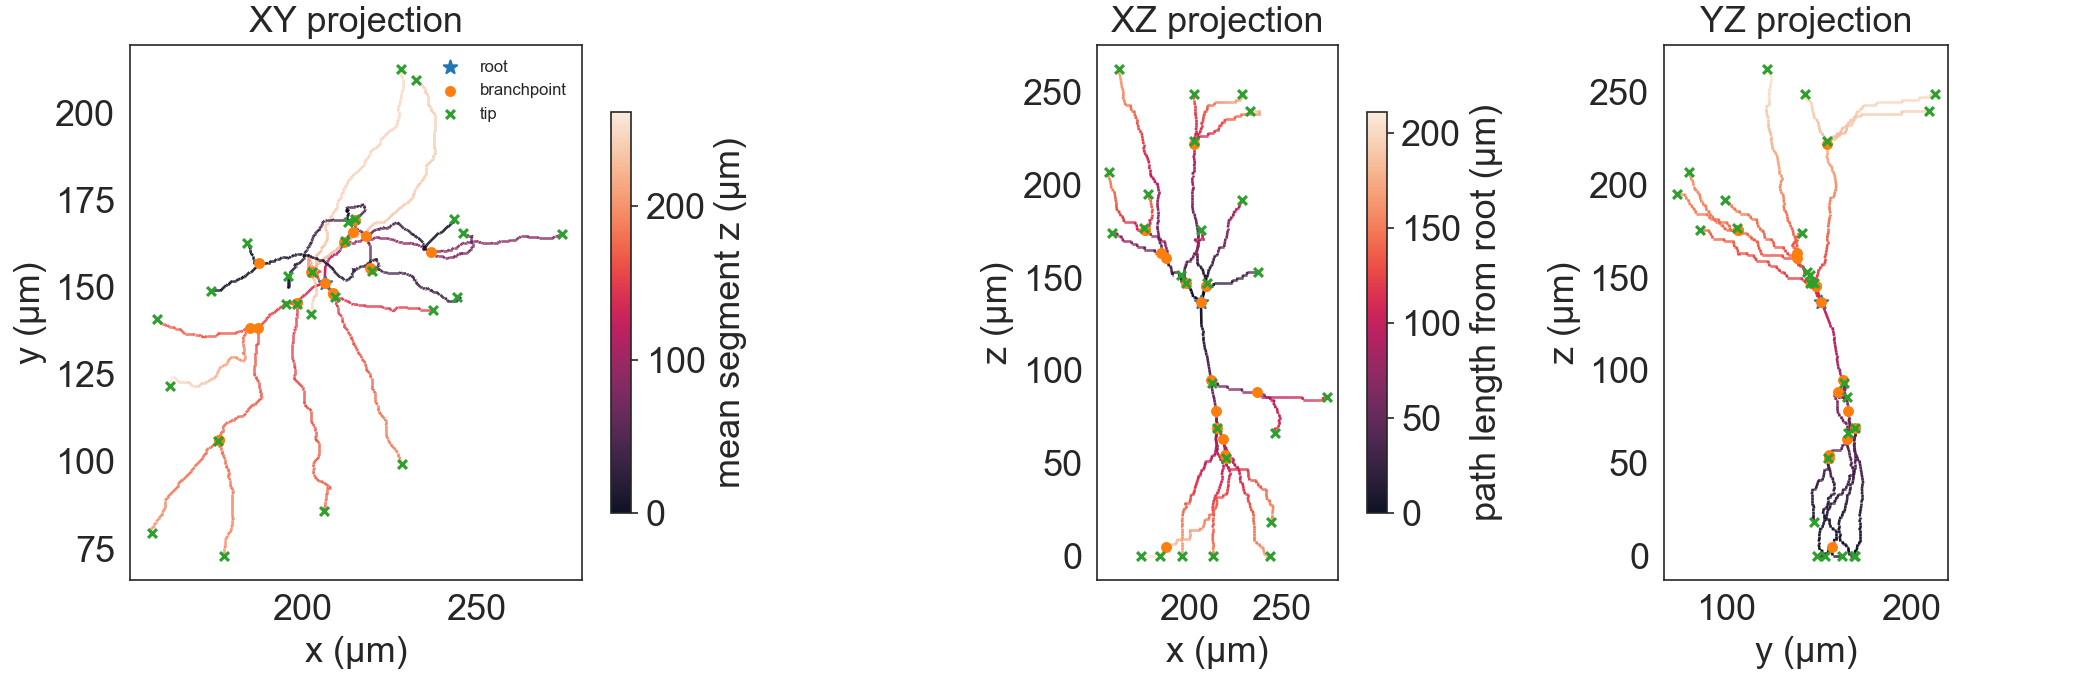

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
views = [((0, 1), "XY projection", "x (µm)", "y (µm)", seg_mid_z, "mean segment z (µm)"),
         ((0, 2), "XZ projection", "x (µm)", "z (µm)", seg_mid_path, "path length from root (µm)"),
         ((1, 2), "YZ projection", "y (µm)", "z (µm)", seg_mid_z, "mean segment z (µm)")]

for ax, (dims, title, xlabel, ylabel, values, cbar_label) in zip(axes, views):
    lc = LineCollection(segments[:, :, dims], linewidths=1.25, alpha=0.95)
    lc.set_array(values)
    ax.add_collection(lc)
    ax.autoscale()
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Mark graph landmarks. Keep these small so the morphology stays readable.
    root = swc[swc["is_root"]]
    bp = swc[swc["is_branchpoint"]]
    tip = swc[swc["is_tip"]]
    ax.scatter(root.iloc[:, [2 + dims[0], 2 + dims[1]]].iloc[:, 0], root.iloc[:, [2 + dims[0], 2 + dims[1]]].iloc[:, 1], s=45, marker="*", label="root", zorder=5)
    ax.scatter(bp.iloc[:, [2 + dims[0], 2 + dims[1]]].iloc[:, 0], bp.iloc[:, [2 + dims[0], 2 + dims[1]]].iloc[:, 1], s=18, marker="o", label="branchpoint", zorder=5)
    ax.scatter(tip.iloc[:, [2 + dims[0], 2 + dims[1]]].iloc[:, 0], tip.iloc[:, [2 + dims[0], 2 + dims[1]]].iloc[:, 1], s=18, marker="x", label="tip", zorder=5)

axes[0].legend(frameon=False, loc="best", fontsize=8)
fig.colorbar(axes[0].collections[0], ax=axes[0], shrink=0.75, label="mean segment z (µm)")
fig.colorbar(axes[1].collections[0], ax=axes[1], shrink=0.75, label="path length from root (µm)")
fig.suptitle(Path(swc_path).name, y=1.04)
plt.show()

In [30]:
views[0][0]

(0, 1)

<IPython.core.display.Javascript object>


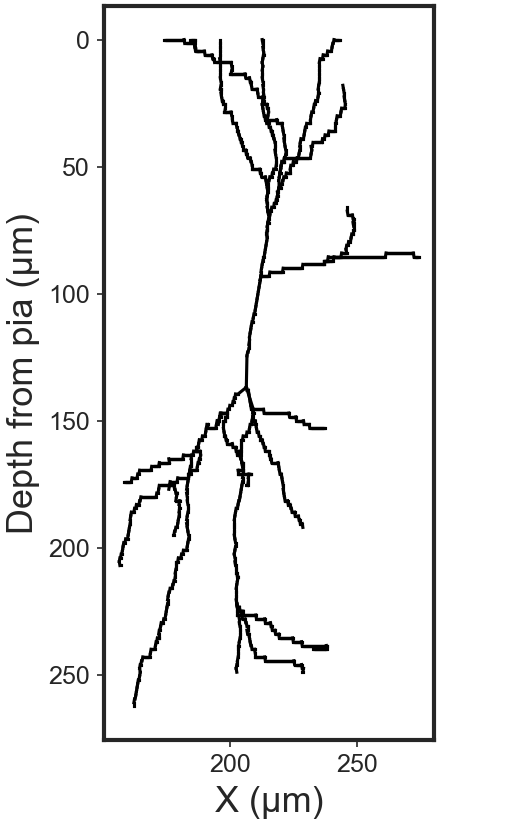

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\andrew.shelton\Anaconda3\lib\site-packages\fontTools\misc\py23.py:11: DeprecationWarning: The py23 module has been deprecated and will be removed in a future release. Please update your code.
  warnings.warn(


In [63]:
fig, ax = plt.subplots( figsize=(3.5, 5.5), constrained_layout=True)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

views = [
#     ((0, 1), "XY projection", "x (µm)", "y (µm)", seg_mid_z, "mean segment z (µm)"),
#          ((0, 2), "XZ projection", "x (µm)", "z (µm)", seg_mid_path, "path length from root (µm)"),
         ((0, 2), "YZ projection", "y (µm)", "z (µm)", seg_mid_z, "mean segment z (µm)")]

for i, (dims, title, xlabel, ylabel, values, cbar_label) in enumerate(views):
    lc = LineCollection(segments[:, :, dims], linewidths=1.5, alpha=1,capstyle='projecting',color='k')
    lc.set_array(values)
    ax.add_collection(lc)
    ax.autoscale()
    ax.set_aspect("equal", adjustable="box")
#     ax.set_title(title)
    ax.set_xlabel('X (\u03BCm)')
    ax.set_ylabel('Depth from pia (\u03BCm)')
    ax.invert_yaxis()

    # Mark graph landmarks. Keep these small so the morphology stays readable.
    root = swc[swc["is_root"]]
    bp = swc[swc["is_branchpoint"]]
    tip = swc[swc["is_tip"]]

for spine in ['left','right','top','bottom']:
    ax.spines[spine].set_linewidth(2)
    
ax.legend(frameon=False, loc="best", fontsize=8)
fig.suptitle(Path(swc_path).name, y=1.04)
filen = 'superstack_morphology_xz'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

In [48]:
swc

,id,type,x,y,z,r,parent,seg_len_um,n_children,is_root,is_tip,is_branchpoint,path_len_um,branch_order
0,1,0,206.25,151.1875,136.875,0.000,-1,0.000000,4,True,False,True,0.000000,0
1,2,0,206.25,151.1875,136.875,0.000,1,0.000000,1,False,False,False,0.000000,1
2,3,0,206.50,150.7500,138.000,0.125,2,1.232693,1,False,False,False,1.232693,1
3,4,0,206.75,150.5000,138.000,0.125,3,0.353553,1,False,False,False,1.586246,1
4,5,0,207.00,150.2500,138.000,0.125,4,0.353553,1,False,False,False,1.939799,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3124,3125,0,184.75,161.5000,0.000,0.125,3124,0.250000,1,False,False,False,201.075526,6
3125,3126,0,184.50,161.7500,0.000,0.125,3125,0.353553,1,False,False,False,201.429079,6
3126,3127,0,184.50,162.0000,0.000,0.125,3126,0.250000,1,False,False,False,201.679079,6
3127,3128,0,184.25,162.2500,0.000,0.125,3127,0.353553,1,False,False,False,202.032632,6


## 3D skeleton view

Useful for checking whether the tracing geometry makes sense across depth. Uncomment `%matplotlib widget` in the imports cell for interactive rotation locally.

<IPython.core.display.Javascript object>


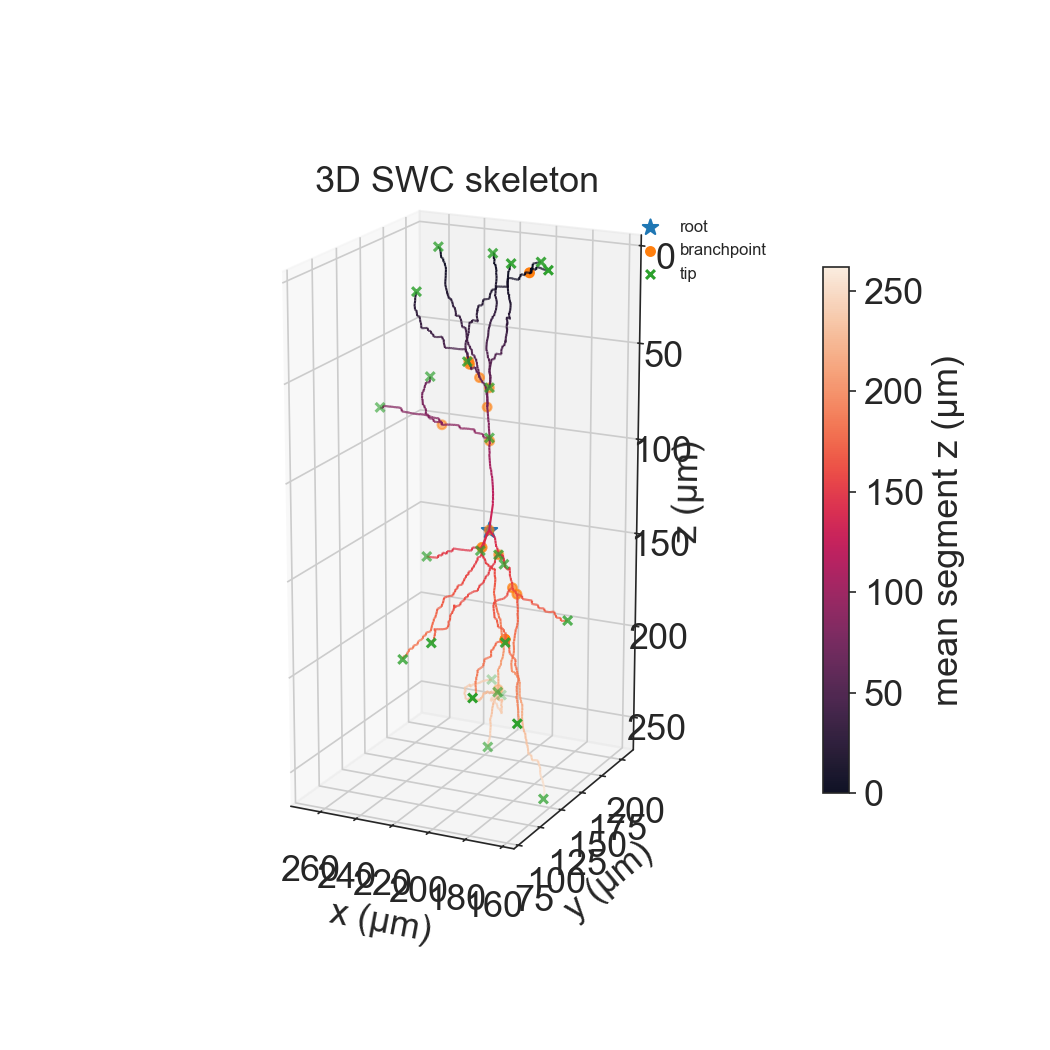

In [16]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

lc3d = Line3DCollection(segments, linewidths=1.0, alpha=0.95)
lc3d.set_array(seg_mid_z)
ax.add_collection3d(lc3d)

root = swc[swc["is_root"]]
bp = swc[swc["is_branchpoint"]]
tip = swc[swc["is_tip"]]
ax.scatter(root["x"], root["y"], root["z"], s=60, marker="*", label="root")
ax.scatter(bp["x"], bp["y"], bp["z"], s=18, marker="o", label="branchpoint")
ax.scatter(tip["x"], tip["y"], tip["z"], s=18, marker="x", label="tip")

xyz_min = swc[["x", "y", "z"]].min()
xyz_max = swc[["x", "y", "z"]].max()
ax.set_xlim(xyz_min["x"], xyz_max["x"])
ax.set_ylim(xyz_min["y"], xyz_max["y"])
ax.set_zlim(xyz_min["z"], xyz_max["z"])
ax.set_box_aspect((xyz_max - xyz_min).to_numpy())
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_zlabel("z (µm)")
ax.view_init(elev=24, azim=-55)
ax.legend(frameon=False, fontsize=8)
fig.colorbar(lc3d, ax=ax, shrink=0.65, label="mean segment z (µm)")
ax.set_title("3D SWC skeleton")
plt.show()

## Optional: overlay the SWC on the original TIFF MIP

This uses the voxel size from the SWC header to convert SWC micron coordinates back into image pixels. It will skip automatically if there is no TIFF stack in `DATA_DIR`.

<IPython.core.display.Javascript object>


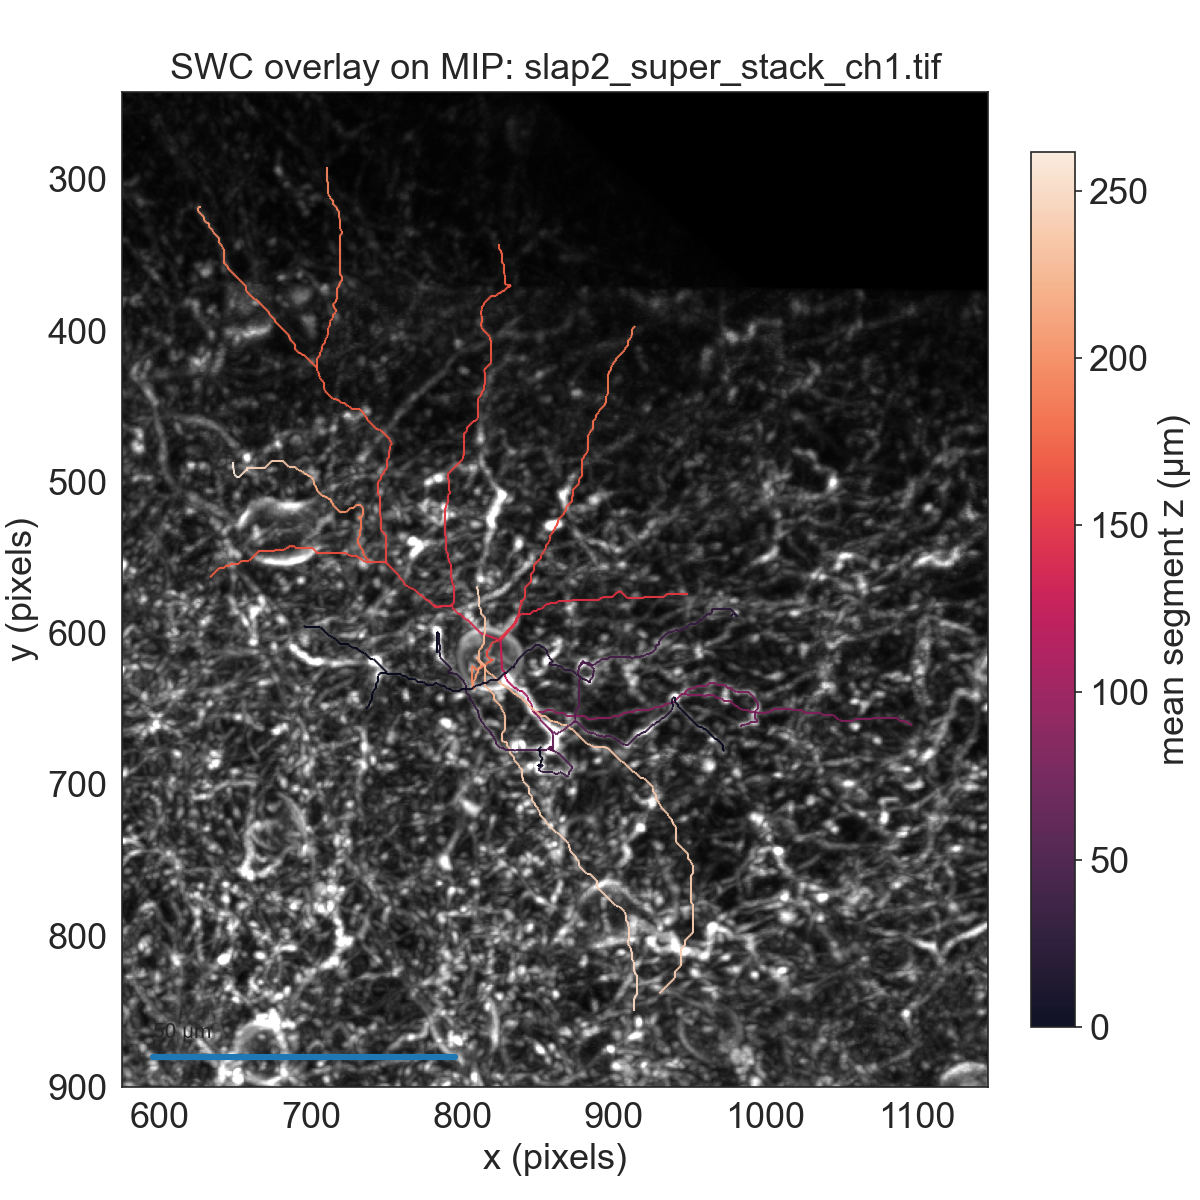

In [20]:
if TIFF_PATH is None:
    print("No TIFF found in DATA_DIR. Set TIFF_PATH to the original stack to make a morphology-over-image MIP overlay.")
else:
    try:
        import tifffile
        img = tifffile.imread(TIFF_PATH)
        mip = np.nanmax(img.reshape((-1,) + img.shape[-2:]), axis=0) if img.ndim > 2 else img
        vx, vy, vz = swc_meta.get("voxel_size_um", (1, 1, 1))
        seg_px = segments.copy()
        seg_px[:, :, 0] /= vx
        seg_px[:, :, 1] /= vy

        vmin, vmax = np.nanpercentile(mip, [1, 99.8])
        fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
        ax.imshow(mip, cmap="gray", vmin=vmin, vmax=vmax)
        lc = LineCollection(seg_px[:, :, [0, 1]], linewidths=1.0, alpha=0.95)
        lc.set_array(seg_mid_z)
        ax.add_collection(lc)
        ax.set_title(f"SWC overlay on MIP: {TIFF_PATH.name}")
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_xlim(max(seg_px[:, :, 0].min() - 50, 0), min(seg_px[:, :, 0].max() + 50, mip.shape[1]))
        ax.set_ylim(min(seg_px[:, :, 1].max() + 50, mip.shape[0]), max(seg_px[:, :, 1].min() - 50, 0))
        fig.colorbar(lc, ax=ax, shrink=0.75, label="mean segment z (µm)")

        # Scale bar, computed from voxel size.
        bar_um = 50
        x0, y0 = ax.get_xlim()[0] + 20, ax.get_ylim()[0] - 20
        ax.plot([x0, x0 + bar_um / vx], [y0, y0], lw=3)
        ax.text(x0, y0 - 10, f"{bar_um} µm", va="bottom")
        plt.show()
    except Exception as e:
        print("TIFF overlay failed:", repr(e))

## Inspect individual SNT paths from the `.traces` file

The `.traces` file is gzipped XML from SNT. This cell plots the traced paths before they are represented as a single SWC graph, which is helpful for catching path discontinuities, duplicate fragments, or odd coordinate scaling.

Loaded 26 paths from no .traces file
{'samplespacing': {'x': '0.25', 'y': '0.25', 'z': '1.5', 'units': 'µm'}, 'imagesize': {'width': '1549', 'height': '1413', 'depth': '176'}}


C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42032\2761755639.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  pts[c] = pd.to_numeric(pts[c], errors="ignore")


,path_id,name,n_points,reallength_um,primary
0,1,Path 1,17,12.997081,true
1,2,Path 2,35,48.664981,false
2,3,Path 3,94,100.612025,false
3,4,Path 4,23,17.291346,false
4,5,Path 5,197,93.243337,false
5,6,Path 6,116,37.649973,false
6,7,Path 7,31,27.950904,false
7,8,Path 8,252,76.964816,false
8,9,Path 9,255,90.315239,false
9,10,Path 10,49,34.158844,false


<IPython.core.display.Javascript object>


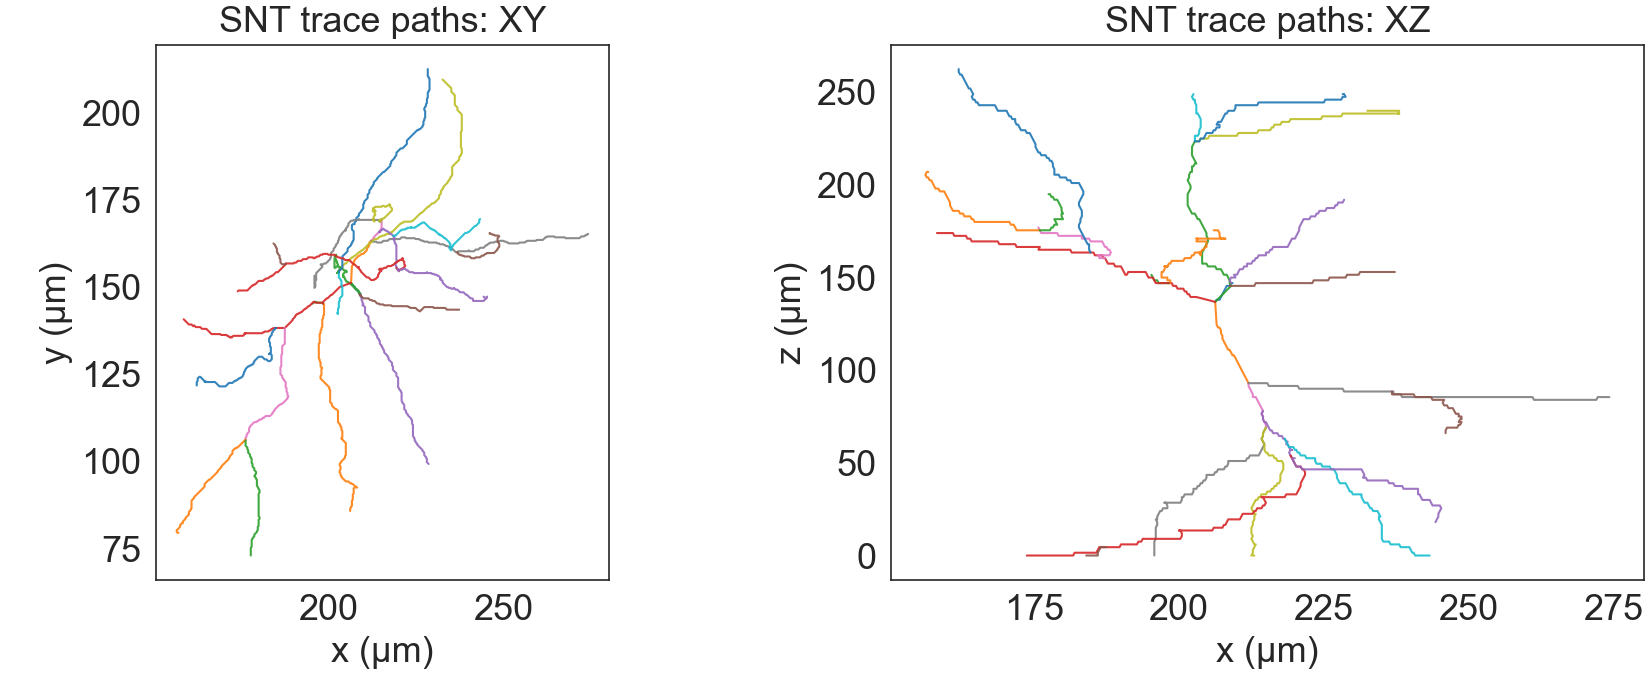

In [22]:
def read_snt_traces(path):
    if path is None:
        return [], {}
    raw = Path(path).read_bytes()
    if raw.startswith(b"\x1f\x8b"):
        raw = gzip.decompress(raw)
    root = ET.fromstring(raw)
    meta = {
        "samplespacing": root.find("samplespacing").attrib if root.find("samplespacing") is not None else {},
        "imagesize": root.find("imagesize").attrib if root.find("imagesize") is not None else {},
    }
    paths = []
    for p in root.findall("path"):
        pts = pd.DataFrame([point.attrib for point in p.findall("point")])
        for c in pts.columns:
            pts[c] = pd.to_numeric(pts[c], errors="ignore")
        paths.append({"attrs": p.attrib, "points": pts})
    return paths, meta

trace_paths, trace_meta = read_snt_traces(tracing_path)
print(f"Loaded {len(trace_paths)} paths from {TRACES_PATH.name if TRACES_PATH else 'no .traces file'}")
print(trace_meta)

if trace_paths:
    path_summary = pd.DataFrame({
        "path_id": [p["attrs"].get("id") for p in trace_paths],
        "name": [p["attrs"].get("name") for p in trace_paths],
        "n_points": [len(p["points"]) for p in trace_paths],
        "reallength_um": [float(p["attrs"].get("reallength", np.nan)) for p in trace_paths],
        "primary": [p["attrs"].get("primary", "false") for p in trace_paths],
    })
    display(path_summary.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    for p in trace_paths:
        pts = p["points"]
        if {"xd", "yd", "zd"}.issubset(pts.columns):
            axes[0].plot(pts["xd"], pts["yd"], lw=1.0, alpha=0.9)
            axes[1].plot(pts["xd"], pts["zd"], lw=1.0, alpha=0.9)
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].set_title("SNT trace paths: XY")
    axes[1].set_title("SNT trace paths: XZ")
    for ax in axes:
        ax.set_xlabel("x (µm)")
    axes[0].set_ylabel("y (µm)")
    axes[1].set_ylabel("z (µm)")
    plt.show()

## Quick extracted-measurement summary

This combines direct SWC-derived metrics with SNT-exported measurements, when those CSVs are available. Agreement between `Cable length` and the SWC-derived sum is a useful first sanity check.

source,SWC-derived
metric,
Cable length (µm),1633.537
Max path length (µm),211.374
No. branch points,17.000
No. branch segments,42.000
No. tips,26.000


<IPython.core.display.Javascript object>


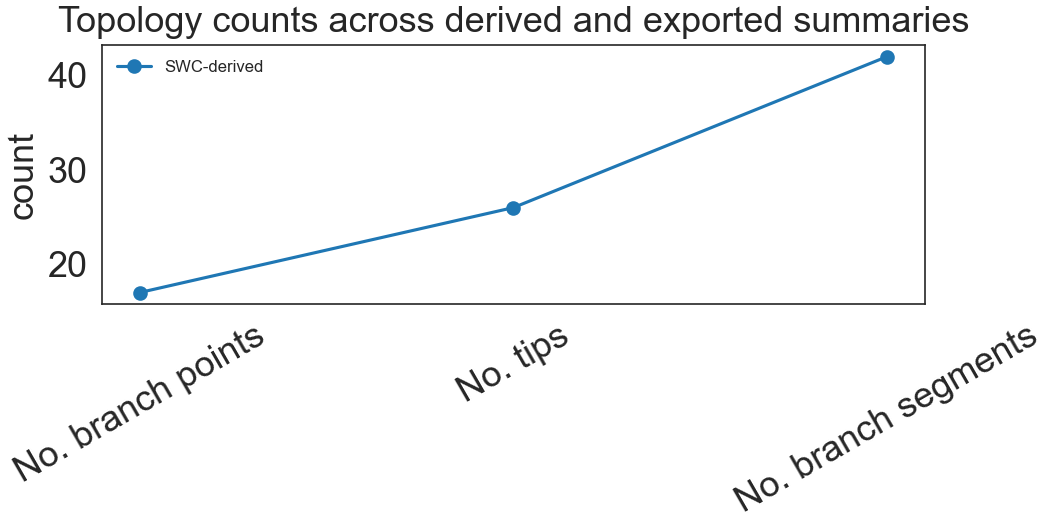

In [23]:
def read_optional_csv(path):
    return pd.read_csv(path) if path is not None and Path(path).exists() else None

snt_meas = read_optional_csv(SNT_MEAS_PATH)
quick_meas = read_optional_csv(QUICK_MEAS_PATH)
sholl = read_optional_csv(SHOLL_PATH)

rows = []
rows.append({"source": "SWC-derived", "metric": "Cable length (µm)", "value": swc["seg_len_um"].sum()})
rows.append({"source": "SWC-derived", "metric": "No. branch points", "value": swc["is_branchpoint"].sum()})
rows.append({"source": "SWC-derived", "metric": "No. tips", "value": swc["is_tip"].sum()})
rows.append({"source": "SWC-derived", "metric": "No. branch segments", "value": len(branches)})
rows.append({"source": "SWC-derived", "metric": "Max path length (µm)", "value": swc["path_len_um"].max()})

for label, df in [("SNT Measurements", snt_meas), ("QuickMeasurements", quick_meas)]:
    if df is None or df.empty:
        continue
    rename = {
        "Cable length (µm) [Single value]": "Cable length (µm)",
        "No. of branch points [Single value]": "No. branch points",
        "No. of tips [Single value]": "No. tips",
        "No. of branches [Single value]": "No. branches",
        "No. of primary branches [Single value]": "No. primary branches",
        "No. of terminal branches [Single value]": "No. terminal branches",
        "Branch length (µm) [Mean]": "Mean branch length (µm)",
        "Branch length (µm) [MEAN]": "Mean branch length (µm)",
    }
    for col, metric in rename.items():
        if col in df.columns:
            rows.append({"source": label, "metric": metric, "value": pd.to_numeric(df.loc[0, col], errors="coerce")})

metric_summary = pd.DataFrame(rows)
display(metric_summary.pivot_table(index="metric", columns="source", values="value", aggfunc="first").round(3))

plot_metrics = metric_summary[metric_summary["metric"].isin(["No. branch points", "No. tips", "No. branches", "No. branch segments"])]
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
for source, g in plot_metrics.groupby("source"):
    ax.plot(g["metric"], g["value"], marker="o", lw=1.5, label=source)
ax.set_ylabel("count")
ax.set_title("Topology counts across derived and exported summaries")
ax.tick_params(axis="x", rotation=30)
ax.legend(frameon=False, fontsize=8)
plt.show()

## Small morphology analyses

These are intended as fast, presentation-friendly checks rather than a full morphometric analysis: branch length distribution, cable length by depth, and branch order versus distance from the root.

<IPython.core.display.Javascript object>


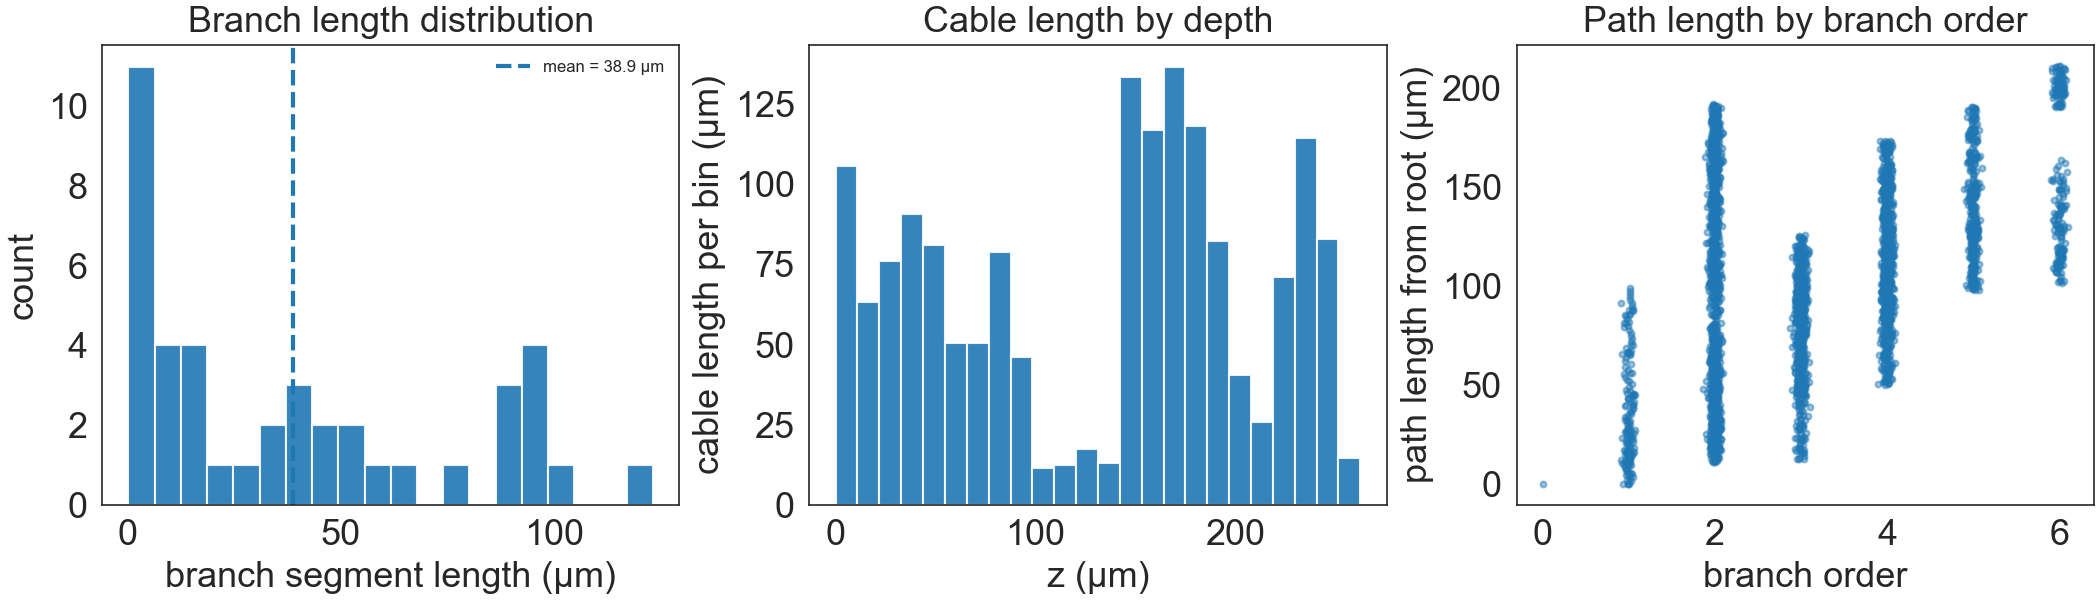

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

axes[0].hist(branches["length_um"], bins=20, alpha=0.9)
axes[0].axvline(branches["length_um"].mean(), lw=2, linestyle="--", label=f"mean = {branches['length_um'].mean():.1f} µm")
axes[0].set_xlabel("branch segment length (µm)")
axes[0].set_ylabel("count")
axes[0].set_title("Branch length distribution")
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(swc["z"], bins=24, weights=swc["seg_len_um"], alpha=0.9)
axes[1].set_xlabel("z (µm)")
axes[1].set_ylabel("cable length per bin (µm)")
axes[1].set_title("Cable length by depth")

jitter = np.random.default_rng(0).normal(0, 0.035, len(swc))
axes[2].scatter(swc["branch_order"] + jitter, swc["path_len_um"], s=8, alpha=0.45)
axes[2].set_xlabel("branch order")
axes[2].set_ylabel("path length from root (µm)")
axes[2].set_title("Path length by branch order")

plt.show()

## Sholl plot

Plots intersections versus radius from the exported SNT Sholl table. The rolling median is only for visualization; keep the raw dots visible when assessing structure.

In [25]:
if sholl is None:
    print("No Sholl table found.")
else:
    sholl = sholl.rename(columns={c: c.strip() for c in sholl.columns}).sort_values("Radius")
    sholl["Inters_smooth"] = sholl["Inters."].rolling(31, center=True, min_periods=1).median()
    imax = sholl["Inters."].idxmax()

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(sholl["Radius"], sholl["Inters."], ".", ms=2, alpha=0.25, label="raw intersections")
    ax.plot(sholl["Radius"], sholl["Inters_smooth"], lw=2, label="rolling median")
    ax.scatter(sholl.loc[imax, "Radius"], sholl.loc[imax, "Inters."], s=45, zorder=5, label="max")
    ax.annotate(
        f"max = {sholl.loc[imax, 'Inters.']:.0f}\nr = {sholl.loc[imax, 'Radius']:.1f} µm",
        xy=(sholl.loc[imax, "Radius"], sholl.loc[imax, "Inters."]),
        xytext=(8, 10), textcoords="offset points",
    )
    ax.set_xlabel("radius from root / center (µm)")
    ax.set_ylabel("intersections")
    ax.set_title("Sholl intersections")
    ax.legend(frameon=False)
    plt.show()

    display(sholl[["Radius", "Inters.", "Length"]].describe().round(3))

No Sholl table found.


## Save figures

Rerun the plotting cells with `SAVE_FIGS = True` and add `fig.savefig(...)` lines as needed, or use this small helper for the currently active figure.

In [ ]:
FIG_DIR = DATA_DIR / "morphology_figures"
FIG_DIR.mkdir(exist_ok=True)

# Example: save the currently active figure after a plotting cell.
# plt.gcf().savefig(FIG_DIR / f"{SWC_PATH.stem}_figure.png", bbox_inches="tight")
print("Figure output folder:", FIG_DIR)

## Notes for interpretation

- Use the **SWC-derived cable length** as the most direct check that the skeleton loaded correctly. It should closely match the SNT-exported cable length.
- If image overlay is shifted, first check whether the SWC header says coordinates are in **µm** or **pixels**, and whether the TIFF was cropped/resampled after tracing.
- For your SLAP2 stacks, the XY scaling is typically much finer than Z. Always inspect XY and XZ/YZ projections before trusting a single 2D render.
- Branch length and Sholl plots are useful for comparing reconstructions across cells, but only after checking that each trace was completed with comparable stopping criteria.